# Objetivo do trabalho
Uso do resNet152 para detecção de cancer de intestino
- Dateset: LC25000
- 5000 imagens de não cancer
- 5000 imagens de cancer
- resolução transformadas: 32 x 32 pixeis

In [1]:
!pip install -q pennylane
!pip install -q pennylane-lightning[gpu]
import pennylane as qml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 98.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 165.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 217.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 23.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 44.4 MB/s eta 0:00:00:00:0100:01


In [2]:
import tqdm
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import kagglehub
import shutil
from typing import Tuple
from PIL import Image
from imblearn.combine import SMOTETomek
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
import os
import datetime
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
from tabulate import tabulate
import seaborn as sns
import copy

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")

Using: NVIDIA H100 80GB HBM3
CUDA: 12.6


In [4]:
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls lung_colon_image_set

100%|██████████| 1.76G/1.76G [00:11<00:00, 159MB/s] 

Extracting files...


colon_image_sets  lung_image_sets


In [5]:
def generate_csv(path):
    path_to_dataset = pathlib.Path(path)
    LC25000Formatter(input_path = path_to_dataset, output_csv = "nb_lc25000.csv").run()


def get_formatted_datasets(path="/content/lung_colon_image_set/colon_image_sets", csv_path="/content/nb_lc25000.csv"):
    generate_csv(path)

    dataframe = pd.read_csv(csv_path)
    x_train, x_test, y_train, y_test = train_test_split(
        dataframe["path"],
        dataframe["label"],
        test_size=0.2,
        random_state=42,
        stratify=dataframe["label"]
    )

    df_train = pd.DataFrame({"path": x_train, "label": y_train})
    df_test = pd.DataFrame({"path": x_test, "label": y_test})  

    X_train, X_validation, y_train, y_validation = train_test_split(
    df_train["path"],
    df_train["label"],
    test_size=0.1,
    random_state=42,
    stratify=df_train["label"]
    )

    df_train = pd.DataFrame({"path": X_train, "label": y_train})
    df_validation = pd.DataFrame({"path": X_validation, "label": y_validation})


    return df_train, df_validation, df_test

class LC25000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "colon_n": int(0),
            "colon_aca": int(1)
        }
        image_extensions = ['.jpg', '.jpeg', '.png']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df

In [6]:
class LC25000Dataset(Dataset):
    def __init__(self, df, target_column, transforms=None):
        self._df = df.reset_index(drop=True)
        self._target_column = target_column
        self._transforms = transforms

    def __len__(self):
        return len(self._df)

    def __getitem__(self, idx):
        row = self._df.iloc[idx]
        image_file_path = row["path"]


        if not os.path.exists(image_file_path):
            raise FileNotFoundError(f"Imagem não encontrada: {image_file_path}")

        image = Image.open(image_file_path).convert("RGB")
        image = np.array(image)
        if self._transforms is not None:
            image = self._transforms(image=image)["image"]
        label = row[self._target_column]
        return image, label

    def show_img(self, idx):
        '''Plot image'''
        img, label = self.__getitem__(idx)
        if isinstance(img, torch.Tensor):
            img = img.numpy().transpose(1, 2, 0)
        plt.figure(figsize=(16, 8))
        plt.axis('off')
        plt.imshow(img)
        plt.title(label)
        plt.pause(0.001)

class LC25000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


class LC25000DatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(32, 32),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(32, 32),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

def get_dataloaders(df_train, df_validation, df_test, batch_size = 1, num_workers = 0, memory_mode = False):
    if not memory_mode:
        dataset_train = LC25000Dataset(
            df_train,
            transforms=LC25000DatasetConfig.TRAIN_TRANSFORMS,
            target_column="label",
        )

        dataset_validation = LC25000Dataset(
            df_validation,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataset_test = LC25000Dataset(
            df_test,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataloader_train = DataLoader(dataset_train, batch_size= batch_size,pin_memory = True, shuffle= True, num_workers = num_workers)
        dataloader_validation = DataLoader(dataset_validation, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)
        dataloader_test = DataLoader(dataset_test, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)

        return dataloader_train, dataloader_validation, dataloader_test

    else:
        dataset_train = LC25000DatasetMemory(
            df_train,
            transforms=LC25000DatasetConfig.TRAIN_TRANSFORMS,
            target_column="label",
        )

        dataset_validation = LC25000DatasetMemory(
            df_validation,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataset_test = LC25000DatasetMemory(
            df_test,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataloader_train = DataLoader(dataset_train, batch_size= batch_size,pin_memory = True, shuffle= True, num_workers = num_workers)
        dataloader_validation = DataLoader(dataset_validation, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)
        dataloader_test = DataLoader(dataset_test, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)

        return dataloader_train, dataloader_validation, dataloader_test

In [7]:
df_train, df_validation, df_test = get_formatted_datasets()
print(f"\nNumber of images in training dataset: {len(df_train)}")
print(f"Number of images in test dataset: {len(df_test)}")
print(f"Number of images in validation dataset: {len(df_validation)}")

100%|██████████| 10002/10002 [00:00<00:00, 39539.03it/s]


CSV salvo com sucesso em: nb_lc25000.csv

Number of images in training dataset: 7200
Number of images in test dataset: 2000
Number of images in validation dataset: 800


In [8]:
batch_size = 32
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test, batch_size, 2, memory_mode = True)

### hiperparametros
- numero de canais de entrada: 3
- numero de classes de saída: 2
- taxa de aprendizado: 0.001
- Otimizador: Adam
- número de épocas: 20

In [9]:
in_channels = 3
output_features = 2
learning_rate = 1e-2

In [10]:
def quanvolution(image, circuit, patch_size, n_qubits):
    """
    Perform quanvolution on the input image using the given quantum circuit.
    
    Args:
    - image (ndarray): The input image (2D or 3D with channels).
    - circuit (function): The quantum circuit function to extract features.
    - patch_size (int): The size of the patches to divide the image into.
    - n_qubits (int): Number of qubits in the quantum circuit.
    
    Returns:
    - out (ndarray): The output tensor after quanvolution.
    """
    if image.ndim == 2:
        image = np.expand_dims(image, axis=-1)
    
    height_patches = image.shape[0] // patch_size
    width_patches = image.shape[1] // patch_size
    
    out = np.zeros((height_patches, width_patches, n_qubits))
    
    for j in range(height_patches):
        for k in range(width_patches):
            patch = []
            for i in range(patch_size):
                for l in range(patch_size):
                    if (j * patch_size + i < image.shape[0]) and (k * patch_size + l < image.shape[1]):
                        patch.append(image[j * patch_size + i, k * patch_size + l, 0])
                    else:
                        patch.append(0)
            
            q_results = circuit(patch)

            # Camada de atenção relacionar os patches e multiplicar atencao pelas features !!!
            
            for c in range(n_qubits):
                out[j, k, c] = q_results[c]
    
    return out

def quanvolution_batch(images, circuit, patch_size, n_qubits):
    """
    Applies quanvolution to a batch of images.

    Args:
    - images: Input tensor (batch_size, H, W, C).
    - circuit: Quantum circuit used for the quanvolution.
    - patch_size: Size of the patches used in the quanvolution.
    - n_qubits: Number of qubits in the quantum circuit.

    Returns:
    - Processed tensor after quanvolution.
    """
    batch_size = images.shape[0]
    processed = [
        quanvolution(images[i].detach().cpu().numpy(), circuit, patch_size, n_qubits)
        for i in range(batch_size)
    ]

    processed = np.array(processed)
    return torch.tensor(processed, dtype=torch.float32).to(images.device)

In [11]:
n_qubits = 4
n_layers = 1

rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, n_qubits))

def get_device(n_qubits):
    return qml.device("lightning.gpu", wires=n_qubits)

def define_circuit(rand_params):
    """
    Define a parametrized quantum circuit with custom layers and RandomLayers.

    Args:
    - rand_params: Parameters for the circuit layers.

    Returns:
    - A quantum circuit function (qml.QNode).
    """
    dev = get_device(n_qubits)
    print(dev)

    @qml.qnode(dev, interface='torch')
    def circuit(phi):
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)

        qml.templates.layers.RandomLayers(rand_params, list(range(n_qubits)))

        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]

    return circuit

rand_circuit = define_circuit(rand_params)

phi = np.random.uniform(size=n_qubits)

result = rand_circuit(phi)

# Draw the circuit using qml.draw
circuit_drawer = qml.draw(rand_circuit)
print(circuit_drawer(phi))

<lightning.gpu device (wires=4) at 0x7d162ef1bb90>
0: ──RY(0.34)─╭RandomLayers(M0)─┤  <Z>
1: ──RY(2.46)─├RandomLayers(M0)─┤  <Z>
2: ──RY(1.77)─├RandomLayers(M0)─┤  <Z>
3: ──RY(2.86)─╰RandomLayers(M0)─┤  <Z>

M0 = 
[[4.38192622 4.59625704 5.25194564 4.39547327]]


In [12]:
class QuanvolutionModel(torch.nn.Module):
    def __init__(self, rand_params, input_size = 128, patch_size = 4, n_qubits = 4, num_classes = 2):
        """
        Defines the CNN with quanvolution.

        Args:
        - rand_params: Parameters of the quantum circuit.
        - input_size: Input image size (assumed square).
        - patch_size: Size of patches in quanvolution.
        - n_qubits: Number of qubits in the quantum circuit.
        - num_classes: Number of classes for classification.
        """
        super(QuanvolutionModel, self).__init__()
        self.input_size = input_size
        self.patch_size = patch_size
        self.n_qubits = n_qubits
        self.num_classes = num_classes
        
        # Calculate actual output size after quanvolution
        self.output_patches = input_size // patch_size
        
        self.circuit = define_circuit(rand_params)

        self.flatten = torch.nn.Flatten()
        fc_input_size = (self.output_patches ** 2) * n_qubits
        self.fc = torch.nn.Linear(fc_input_size, num_classes)

    def forward(self, x):
        """
        Passes the data through the network.

        Args:
        - x: Input tensor (batch_size, C, H, W).
        
        Returns:
        - Logarithmic probabilities of the classes (batch_size, num_classes).
        """
        x = x.permute(0, 2, 3, 1)
        x = quanvolution_batch(x, self.circuit, self.patch_size, self.n_qubits)
        x = torch.relu(x)
        x = self.flatten(x)
        x = self.fc(x)
        return torch.nn.functional.log_softmax(x, dim=1)


In [13]:
model = QuanvolutionModel(rand_params, 32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

<lightning.gpu device (wires=4) at 0x7d162eed4ce0>


### Treinamento

In [14]:
criterion = torch.nn.CrossEntropyLoss().to(device)
epochs = 20
train_losses = []

val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1_scores = []
val_aucs = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")

    model.train()
    total_loss = 0.0
    print("\n[Training]")
    for batch_idx, (images, labels) in enumerate(tqdm.tqdm(dataloader_train, desc="Training Batches", bar_format="{desc}: {n}/{total}")):
        images, labels = images.squeeze(1).to(device), labels.squeeze().to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        batch_accuracy = accuracy_score(
            labels.cpu().numpy(), output.argmax(dim=1).cpu().numpy()
        )

        print(f"Loss: {loss.item():.4f}, Accuracy: {batch_accuracy:.3f}")

    epoch_train_loss = total_loss / len(dataloader_train)
    train_losses.append(epoch_train_loss)
    print(f"Epoch {epoch + 1} Training Loss: {epoch_train_loss:.4f}")

    scheduler.step()

    model.eval()
    val_loss = 0.0
    val_labels, val_predictions = [], []

    print("\n[Validation]")
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(tqdm.tqdm(dataloader_validation, desc="Validation Batches", bar_format="{desc}: {n}/{total}")):
            images, labels = images.squeeze(1).to(device), labels.squeeze().to(device)
            output = model(images)
            loss = criterion(output, labels)
            val_loss += loss.item()

            val_labels.append(labels)
            val_predictions.append(output)

            batch_accuracy = accuracy_score(
                labels.cpu().numpy(), output.argmax(dim=1).cpu().numpy()
            )
            print(f"Loss: {loss.item():.4f}, Accuracy: {batch_accuracy:.3f}")

    epoch_val_loss = val_loss / len(dataloader_validation)
    val_losses.append(epoch_val_loss)
    val_labels = torch.cat(val_labels)
    val_predictions = torch.cat(val_predictions)

    val_accuracy = accuracy_score(
        val_labels.cpu().numpy(), val_predictions.argmax(dim=1).cpu().numpy())
    val_precision = precision_score(
        val_labels.cpu().numpy(), val_predictions.argmax(dim=1).cpu().numpy(),
        average="weighted", zero_division=0)
    val_recall = recall_score(
        val_labels.cpu().numpy(), val_predictions.argmax(dim=1).cpu().numpy(),
        average="weighted", zero_division=0)
    val_f1 = f1_score(
        val_labels.cpu().numpy(), val_predictions.argmax(dim=1).cpu().numpy(),
        average="weighted", zero_division=0)
    val_auc = roc_auc_score(
        val_labels.cpu().numpy(), val_predictions[:, 1].cpu().numpy())

    val_accuracies.append(val_accuracy)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1_scores.append(val_f1)
    val_aucs.append(val_auc)

    print(
        f"\nEpoch {epoch + 1} Summary:\n"
        f"Train Loss: {epoch_train_loss:.4f}, "
        f"Val Loss: {epoch_val_loss:.4f}, "
        f"Accuracy: {val_accuracy:.3f}, "
        f"Precision: {val_precision:.3f}, "
        f"Recall: {val_recall:.3f}, "
        f"F1: {val_f1:.3f}, "
        f"AUC: {val_auc:.3f}"
    )

print("Training completed!")



Epoch 1/20

[Training]


Training Batches: 1/225

Loss: 0.7646, Accuracy: 0.469


Training Batches: 2/225

Loss: 0.6990, Accuracy: 0.562


...

Loss: 0.5317, Accuracy: 0.812


Validation Batches: 24/25

Loss: 0.3361, Accuracy: 0.844


Validation Batches: 25/25

Loss: 0.4329, Accuracy: 0.875

Epoch 20 Summary:
Train Loss: 0.4700, Val Loss: 0.4972, Accuracy: 0.772, Precision: 0.773, Recall: 0.772, F1: 0.772, AUC: 0.832
Training completed!


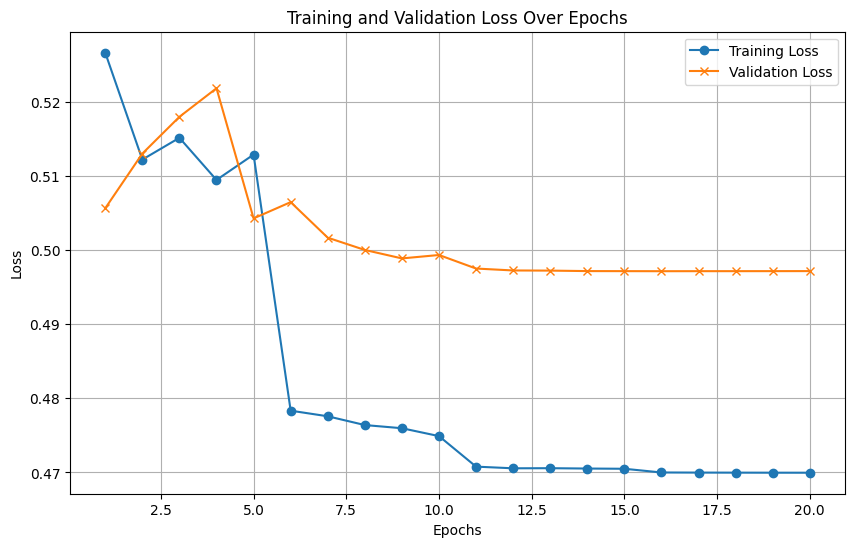

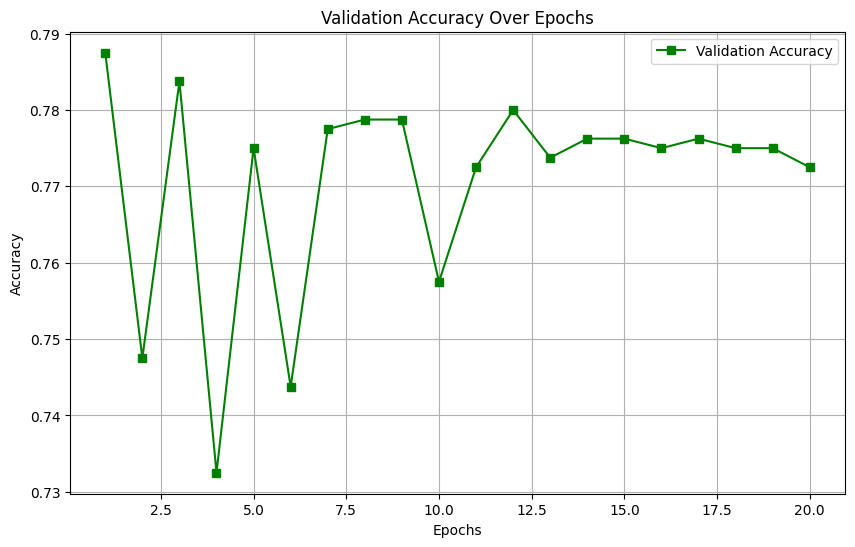

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label="Training Loss", marker='o')
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss", marker='x')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label="Validation Accuracy", marker='s', color='g')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

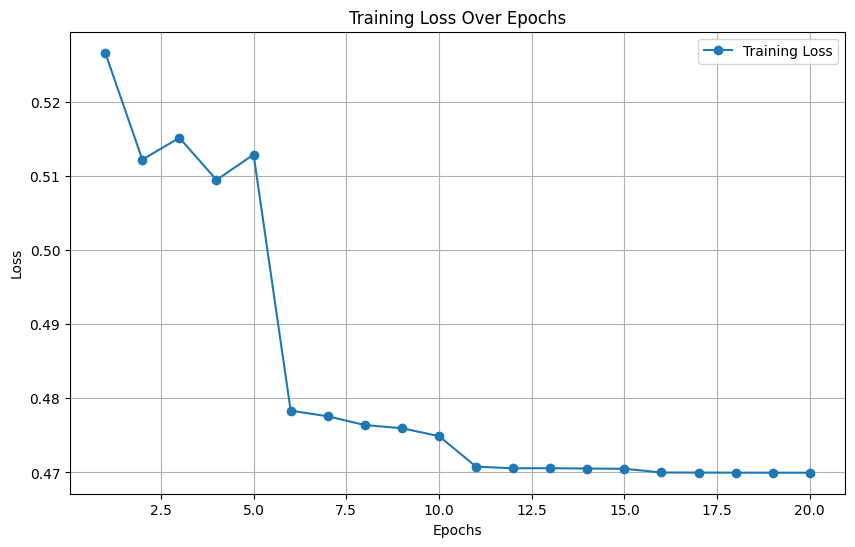

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label="Training Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
test_loss = 0.0
test_labels, test_predictions = [], []

model.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        images, labels = images.squeeze(1).to(device), labels.squeeze().to(device)
        output = model(images)
        loss = criterion(output, labels)
        test_loss += loss.item()
        test_labels.append(labels)
        test_predictions.append(output)

test_labels = torch.cat(test_labels)
test_predictions = torch.cat(test_predictions)

test_probs = torch.exp(test_predictions)

test_accuracy = accuracy_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy()
)
test_precision = precision_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_recall = recall_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_f1 = f1_score(
    test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), 
    average="weighted", zero_division=0
)
test_auc = roc_auc_score(
    test_labels.cpu().numpy(), test_probs[:, 1].cpu().numpy()
)

print("\nFinal Test Evaluation:")
print(f"Test Loss: {test_loss / len(dataloader_test):.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Test AUC: {test_auc:.4f}")



Final Test Evaluation:
Test Loss: 0.4944
Test Accuracy: 0.7790
Test Precision: 0.7805
Test Recall: 0.7790
Test F1 Score: 0.7787
Test AUC: 0.8376


In [18]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{test_accuracy:.4f}"],
["Precisão (weighted)", f"{test_precision:.4f}"],
["Recall (weighted)", f"{test_recall:.4f}"],
["F1-score (weighted)", f"{test_f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.779  │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.7805 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.779  │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.7787 │
╘═════════════════════╧═════════╛


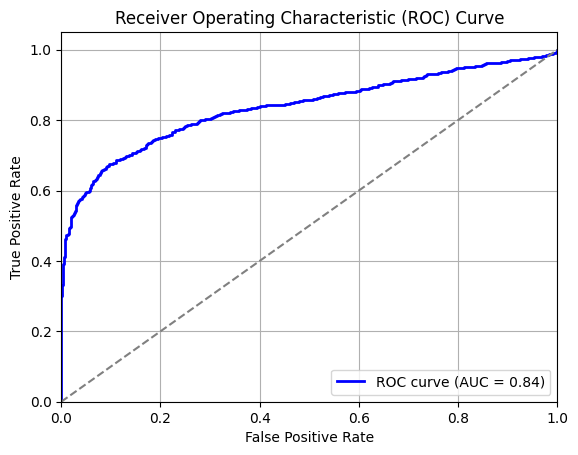

ROC curve data exported to 'roc_curve_data_BreastMNIST.csv'


In [19]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    test_labels.cpu().numpy(), test_probs[:, 1].cpu().numpy()
)
roc_auc = auc(false_positive_rate, true_positive_rate)

plt.figure()
plt.plot(false_positive_rate, true_positive_rate, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

dataset_name = "BreastMNIST"
roc_data = pd.DataFrame({
    'Dataset': [dataset_name] * len(false_positive_rate),
    'False Positive Rate': false_positive_rate,
    'True Positive Rate': true_positive_rate,
    'Thresholds': thresholds
})

print(f"ROC curve data exported to 'roc_curve_data_{dataset_name}.csv'")


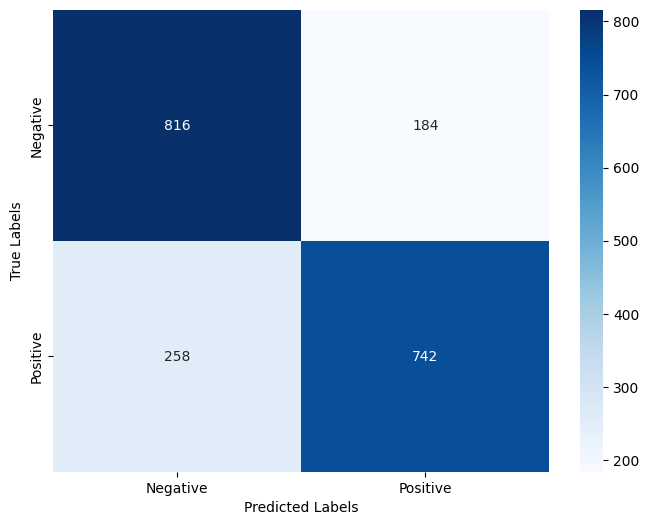

In [20]:
cm = confusion_matrix(test_labels.cpu().numpy(), test_predictions.argmax(dim=1).cpu().numpy(), labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()